In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib as plt

import seaborn as sns

In [ ]:
pip install ucimlrepo

Estamos trabajando con el conjunto de datos de diabetes.

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [ ]:
print('Primeros 5 registros de las características (X):')
display(X.head())

Primeros 5 registros de las características (X):


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4


In [ ]:
print('\nPrimeros 5 registros de las etiquetas (y):')
display(y.head())


Primeros 5 registros de las etiquetas (y):


,Diabetes_binary
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Combine features (X) and targets (y) into a single DataFrame
data_combined = X.copy()
data_combined['Diabetes_binary'] = y

In [ ]:
# Save the combined DataFrame to a CSV file
csv_filename = 'cdc_diabetes_data.csv'
data_combined.to_csv(csv_filename, index=False)

print(f"Dataset guardado exitosamente como '{csv_filename}'")

Dataset guardado exitosamente como 'cdc_diabetes_data.csv'


A partir de aqui empezamos fase de limpieza.


In [ ]:

Diabetes = pd.read_csv("cdc_diabetes_data.csv")

print(Diabetes.iloc[:10, :10])  # primeras 10 filas y 10 columnas

Diabetes.head

Diabetes.shape

Diabetes.drop_duplicates()

print(Diabetes.drop_duplicates())





   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   
5       1         1          1   25       1       0                     0   
6       1         0          1   30       1       0                     0   
7       1         1          1   25       1       0                     0   
8       1         1          1   30       1       0                     1   
9       0         0          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  
0             0       0        1  
1             1       0        0  
2             0       1        0  
3           

In [ ]:
# sin duplicados Diabetes1

Diabetes1 = Diabetes.drop_duplicates()

print(Diabetes1.shape)

print("\nTotal de nulos en la base:")

print(Diabetes1.isnull().sum().sum())

print(Diabetes1.dtypes)

(229474, 22)

Total de nulos en la base:
0
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object


In [ ]:
# para ver una descripcion de los datos de la columna BMI

print(Diabetes1["BMI"].describe())

count    229474.000000
mean         28.687507
std           6.789204
min          12.000000
25%          24.000000
50%          27.000000
75%          32.000000
max          98.000000
Name: BMI, dtype: float64


aqui empezamos de nuevo, nuevo codigo

In [ ]:
#tamanio del dataframe
Diabetes1.shape

(229474, 22)

In [ ]:
#primeras filas (por defecto, primeras 5)
Diabetes1.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [ ]:
#resumen rapido del dataframe
Diabetes1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                229474 non-null  int64
 1   HighChol              229474 non-null  int64
 2   CholCheck             229474 non-null  int64
 3   BMI                   229474 non-null  int64
 4   Smoker                229474 non-null  int64
 5   Stroke                229474 non-null  int64
 6   HeartDiseaseorAttack  229474 non-null  int64
 7   PhysActivity          229474 non-null  int64
 8   Fruits                229474 non-null  int64
 9   Veggies               229474 non-null  int64
 10  HvyAlcoholConsump     229474 non-null  int64
 11  AnyHealthcare         229474 non-null  int64
 12  NoDocbcCost           229474 non-null  int64
 13  GenHlth               229474 non-null  int64
 14  MentHlth              229474 non-null  int64
 15  PhysHlth              229474 non-null  

In [ ]:
# Evaluar dataset y eliminar filas duplicadas
Diabetes1.drop_duplicates()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,0,3,0,5,0,1,5,6,7,0
253676,1,1,1,18,0,0,0,0,0,0,...,0,4,0,0,1,0,11,2,4,1
253677,0,0,1,28,0,0,0,1,1,0,...,0,1,0,0,0,0,2,5,2,0
253678,1,0,1,23,0,0,0,0,1,1,...,0,3,0,0,0,1,7,5,1,0


In [ ]:
# Eliminar filas con nulos
Diabetes1 = Diabetes1.dropna()

# Luego eliminar columnas con nulos
Diabetes1 = Diabetes1.dropna(axis=1)


In [ ]:
Diabetes1.shape

(229474, 22)

En caso de tener valores nulos, se pueden reemplazar por otro valor (la media) utilizando este codigo. Este código toma una columna ""salary"" que contiene valores de salario en formato de cadena, elimina cualquier caracter no numérico, extrae los digitos convierte la columna resultante en valores numéricos de tipo float. El resultado se almacena en una nueva-columna Llamada-""salary numeric. Esto es útil cuando la columna ""salary"" inicial contiene caracteres no numéricos y se desea trabajar con los salarios como valores numéricos:
Diabetes1['salary_numeric'] = Diabetes1['salary'].replace('[^\d.]','', regex=True).str.extract('(\d+)')astype(float)

Sugerencia, con chatgpt podemos pedirle de como transformar una variable que no es numeric para poderla convertir en nu eric y trabajar con ella.

In [ ]:
#Resumen numerico
Diabetes1.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,229474.000000,229474.000000,229474.000000,229474.000000,229474.00000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,...,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000
mean,0.454343,0.441640,0.959481,28.687507,0.46580,0.044816,0.103336,0.733042,0.612675,0.794587,...,0.092921,2.601820,3.509866,4.681219,0.185751,0.439087,8.085068,4.979741,5.888615,0.152945
std,0.497912,0.496584,0.197173,6.789204,0.49883,0.206899,0.304398,0.442371,0.487140,0.404004,...,0.290323,1.064962,7.717643,9.050877,0.388906,0.496277,3.094451,0.992989,2.092888,0.359936
min,0.000000,0.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,4.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000,0.000000
75%,1.000000,1.000000,1.000000,32.000000,1.00000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


In [ ]:
#Resumen estadistico de la columna CholCheck
print(Diabetes1["CholCheck"].describe())


count    229474.000000
mean          0.959481
std           0.197173
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: CholCheck, dtype: float64


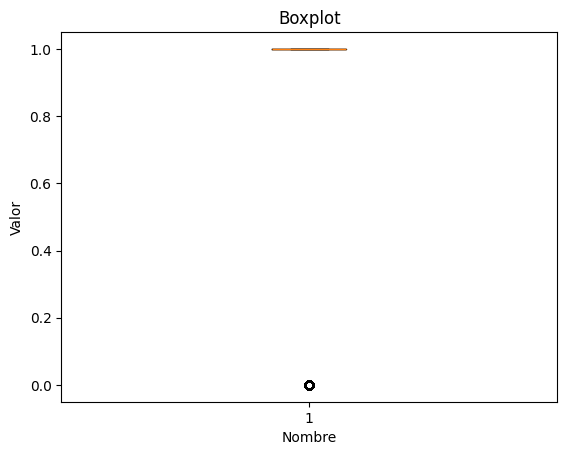

In [ ]:
#Crear un boxplot
import matplotlib.pyplot as plt

plt.boxplot(Diabetes1['CholCheck'])
plt.xlabel('Nombre')       # etiqueta del eje X
plt.ylabel('Valor')        # etiqueta del eje Y
plt.title('Boxplot')       # título del gráfico
#Mostrar grafico
plt.show()


In [ ]:
#Tipo de variable
Diabetes1.dtypes


,0
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64
Veggies,int64


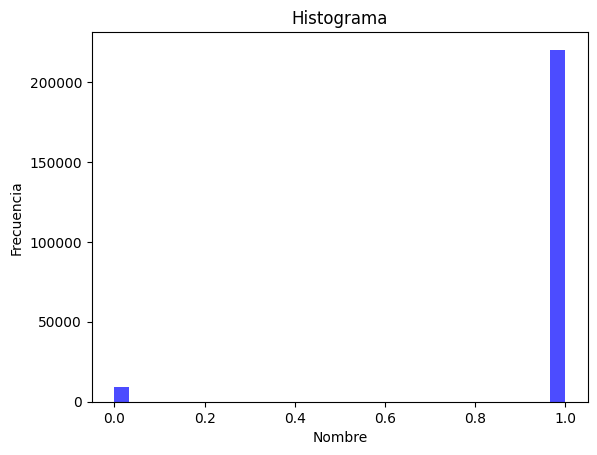

In [ ]:
#Crear histograma
plt.hist(Diabetes1['CholCheck'], bins=30, color='blue', alpha=0.7)
#Anadir etiquetas y nombre
plt.xlabel('Nombre')
plt.ylabel('Frecuencia')
plt.title('Histograma')
#Mostrar el histograma
plt.show()


Para crear un filtro se utiliza la siguiente funcion
Diabetes1=Diabetes1[Diabetes1['salary_numeric']>= 200]

Para eliminar columnas usamos:
Diabetes1.drop('salary', axis=1, implace=True)
La variable salary no existe en nuestro dataframe

In [ ]:
csv_export_filename = 'Diabetes1_cleaned.csv'
Diabetes1.to_csv(csv_export_filename, index=False)
print(f"DataFrame 'Diabetes1' exportado exitosamente como '{csv_export_filename}'")

DataFrame 'Diabetes1' exportado exitosamente como 'Diabetes1_cleaned.csv'


## Descripción de las Columnas del Dataset (Tabla)

| Columna               | Descripción en Español                                                                                                              |
|:----------------------|:------------------------------------------------------------------------------------------------------------------------------------|
| **HighBP**            | Presión arterial alta (0 = no, 1 = sí)                                                                                              |
| **HighChol**          | Colesterol alto (0 = no, 1 = sí)                                                                                                    |
| **CholCheck**         | Control de colesterol realizado en los últimos 5 años (0 = no, 1 = sí)                                                              |
| **BMI**               | Índice de Masa Corporal (IMC)                                                                                                       |
| **Smoker**            | ¿Ha fumado al menos 100 cigarrillos en toda su vida? (0 = no, 1 = sí)                                                                 |
| **Stroke**            | ¿Alguna vez le han dicho que tuvo un derrame cerebral? (0 = no, 1 = sí)                                                             |
| **HeartDiseaseorAttack**| ¿Alguna vez le han dicho que tiene enfermedad coronaria o infarto de miocardio? (0 = no, 1 = sí)                                  |
| **PhysActivity**      | ¿Ha realizado actividad física en los últimos 30 días, aparte de su trabajo habitual? (0 = no, 1 = sí)                                |
| **Fruits**            | ¿Consume frutas 1 o más veces al día? (0 = no, 1 = sí)                                                                              |
| **Veggies**           | ¿Consume verduras 1 o más veces al día? (0 = no, 1 = sí)                                                                            |
| **HvyAlcoholConsump** | Bebedores empedernidos (hombres adultos que han tomado más de 14 copas a la semana y mujeres adultas que han tomado más de 7 copas a la semana) (0 = no, 1 = sí) |
| **AnyHealthcare**     | ¿Tiene algún tipo de cobertura de atención médica, incluyendo seguro de salud, prepago, etc.? (0 = no, 1 = sí)                        |
| **NoDocbcCost**       | ¿Hubo alguna vez en los últimos 12 meses que necesitó ver a un médico pero no pudo debido al costo? (0 = no, 1 = sí)                |
| **GenHlth**           | ¿Diría que, en general, su salud es: (1 = excelente, 2 = muy buena, 3 = buena, 4 = regular, 5 = mala)?                                |
| **MentHlth**          | Ahora, pensando en su salud mental, ¿cuántos días durante los últimos 30 días su salud mental no fue buena? (0-30 días)              |
| **PhysHlth**          | Ahora, pensando en su salud física, ¿cuántos días durante los últimos 30 días su salud física no fue buena? (0-30 días)               |
| **DiffWalk**          | ¿Tiene serias dificultades para caminar o subir escaleras? (0 = no, 1 = sí)                                                         |
| **Sex**               | Sexo (0 = mujer, 1 = hombre)                                                                                                        |
| **Age**               | Categoría de edad de 13 niveles (1 = 18-24, 2 = 25-29, ..., 13 = 80 o más)                                                           |
| **Education**         | Nivel de educación (1 = nunca asistió a la escuela o solo guardería, ..., 6 = universidad de 4 años o más)                          |
| **Income**            | Escala de ingresos (1 = menos de $10,000, ..., 8 = $75,000 o más)                                                                    |
| **Diabetes_binary**   | ¿Ha sido diagnosticado con diabetes? (0 = no diabetes, 1 = prediabetes o diabetes diagnosticada)                                     |